In [1047]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# importing all ML models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# importing validation matrices
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import RandomizedSearchCV


# ***1. Loaded the Dataset***

In [1048]:
df = pd.read_csv('ghosting_dataset2.csv')
df

,last_message_length,response_time_gap,initiator,conversation_length,reply_ratio,avg_response_time,message_tone,emoji_count,question_asked,time_of_day,seen_ignored,past_ghosting_history,reply,ghosted
0,47,9.474770,me,16,0.30,119.597983,enthusiastic,7,0,day,1,1,1,0
1,1,26.082656,me,166,0.86,38.200045,neutral,4,0,night,0,0,1,0
2,27,71.585346,me,200,0.15,63.836544,neutral,3,1,day,1,0,0,1
3,14,4.256288,them,160,0.98,30.483516,enthusiastic,9,0,night,0,1,1,0
4,46,66.767645,them,57,0.39,106.084704,neutral,6,1,night,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,31,6.236081,them,130,0.04,91.787843,dry,4,1,night,1,1,0,1
996,33,61.276902,them,32,0.03,85.399233,enthusiastic,1,1,day,1,0,0,1
997,49,51.260416,me,58,0.29,47.659409,neutral,9,0,night,0,1,1,0
998,10,49.751866,them,152,0.94,12.120685,enthusiastic,6,1,day,0,1,1,0


In [1049]:
df.shape

(1000, 14)

In [1050]:
# are there any missing values?
df.isnull().sum()

,0
last_message_length,0
response_time_gap,0
initiator,0
conversation_length,0
reply_ratio,0
avg_response_time,0
message_tone,0
emoji_count,0
question_asked,0
time_of_day,0


In [1051]:
# are there any duplicated valueS?
df.duplicated().sum()

np.int64(0)

In [1052]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   last_message_length    1000 non-null   int64  
 1   response_time_gap      1000 non-null   float64
 2   initiator              1000 non-null   object 
 3   conversation_length    1000 non-null   int64  
 4   reply_ratio            1000 non-null   float64
 5   avg_response_time      1000 non-null   float64
 6   message_tone           1000 non-null   object 
 7   emoji_count            1000 non-null   int64  
 8   question_asked         1000 non-null   int64  
 9   time_of_day            1000 non-null   object 
 10  seen_ignored           1000 non-null   int64  
 11  past_ghosting_history  1000 non-null   int64  
 12  reply                  1000 non-null   int64  
 13  ghosted                1000 non-null   int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 109.5+ K

In [1053]:
df.describe()

,last_message_length,response_time_gap,conversation_length,reply_ratio,avg_response_time,emoji_count,question_asked,seen_ignored,past_ghosting_history,reply,ghosted
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,25.441000,35.963041,102.333000,0.499800,60.123087,4.939000,0.498000,0.519000,0.503000,0.38200,0.454000
std,14.585035,20.747842,58.840363,0.286556,34.814132,3.081359,0.500246,0.499889,0.500241,0.48612,0.498129
min,1.000000,0.040830,1.000000,0.000000,1.076649,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,13.000000,18.388583,50.000000,0.257500,29.420861,2.000000,0.000000,0.000000,0.000000,0.00000,0.000000
50%,25.000000,36.209344,105.000000,0.490000,59.646288,5.000000,0.000000,1.000000,1.000000,0.00000,0.000000
75%,38.000000,54.561851,154.000000,0.742500,90.955197,7.000000,1.000000,1.000000,1.000000,1.00000,1.000000
max,50.000000,71.919001,200.000000,1.000000,119.963249,10.000000,1.000000,1.000000,1.000000,1.00000,1.000000


In [1054]:
df.head()

,last_message_length,response_time_gap,initiator,conversation_length,reply_ratio,avg_response_time,message_tone,emoji_count,question_asked,time_of_day,seen_ignored,past_ghosting_history,reply,ghosted
0,47,9.474770,me,16,0.30,119.597983,enthusiastic,7,0,day,1,1,1,0
1,1,26.082656,me,166,0.86,38.200045,neutral,4,0,night,0,0,1,0
2,27,71.585346,me,200,0.15,63.836544,neutral,3,1,day,1,0,0,1
3,14,4.256288,them,160,0.98,30.483516,enthusiastic,9,0,night,0,1,1,0
4,46,66.767645,them,57,0.39,106.084704,neutral,6,1,night,0,1,0,1


In [1055]:
# converting the response_time_gap col(float) --> into int datatype --> represents hours
df['response_time_gap'] = df['response_time_gap'].astype(np.int32)
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   last_message_length    1000 non-null   int64  
 1   response_time_gap      1000 non-null   int32  
 2   initiator              1000 non-null   object 
 3   conversation_length    1000 non-null   int64  
 4   reply_ratio            1000 non-null   float64
 5   avg_response_time      1000 non-null   float64
 6   message_tone           1000 non-null   object 
 7   emoji_count            1000 non-null   int64  
 8   question_asked         1000 non-null   int64  
 9   time_of_day            1000 non-null   object 
 10  seen_ignored           1000 non-null   int64  
 11  past_ghosting_history  1000 non-null   int64  
 12  reply                  1000 non-null   int64  
 13  ghosted                1000 non-null   int64  
dtypes: float64(2), int32(1), int64(8), object(3)
memory usage

In [1056]:
# converting the avg_response_time col(float) --> into int datatype --> represents minutes
df['avg_response_time'] = df['avg_response_time'].astype(np.int32)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   last_message_length    1000 non-null   int64  
 1   response_time_gap      1000 non-null   int32  
 2   initiator              1000 non-null   object 
 3   conversation_length    1000 non-null   int64  
 4   reply_ratio            1000 non-null   float64
 5   avg_response_time      1000 non-null   int32  
 6   message_tone           1000 non-null   object 
 7   emoji_count            1000 non-null   int64  
 8   question_asked         1000 non-null   int64  
 9   time_of_day            1000 non-null   object 
 10  seen_ignored           1000 non-null   int64  
 11  past_ghosting_history  1000 non-null   int64  
 12  reply                  1000 non-null   int64  
 13  ghosted                1000 non-null   int64  
dtypes: float64(1), int32(2), int64(8), object(3)
memory usage

In [1057]:
df.head()

,last_message_length,response_time_gap,initiator,conversation_length,reply_ratio,avg_response_time,message_tone,emoji_count,question_asked,time_of_day,seen_ignored,past_ghosting_history,reply,ghosted
0,47,9,me,16,0.30,119,enthusiastic,7,0,day,1,1,1,0
1,1,26,me,166,0.86,38,neutral,4,0,night,0,0,1,0
2,27,71,me,200,0.15,63,neutral,3,1,day,1,0,0,1
3,14,4,them,160,0.98,30,enthusiastic,9,0,night,0,1,1,0
4,46,66,them,57,0.39,106,neutral,6,1,night,0,1,0,1


In [1058]:
# displaying unique values
df.nunique()

,0
last_message_length,50
response_time_gap,72
initiator,2
conversation_length,197
reply_ratio,101
avg_response_time,119
message_tone,3
emoji_count,11
question_asked,2
time_of_day,2


In [1059]:
# displaying all those unique values the occur in the cols --> except for ID, age and result

for col in df.columns:
  numerical_cols = ['last_message_length', 'response_time_gap', 'conversation_length', 'reply_ratio', 'avg_response_time', 'emoji_count']
  if col not in numerical_cols:
    print(f'{col} : {df[col].unique()}')
    # separating it by hyphen(-)
    print("-"*50)

initiator : ['me' 'them']
--------------------------------------------------
message_tone : ['enthusiastic' 'neutral' 'dry']
--------------------------------------------------
question_asked : [0 1]
--------------------------------------------------
time_of_day : ['day' 'night']
--------------------------------------------------
seen_ignored : [1 0]
--------------------------------------------------
past_ghosting_history : [1 0]
--------------------------------------------------
reply : [1 0]
--------------------------------------------------
ghosted : [0 1]
--------------------------------------------------


# ***Exploratoy Data Analysis***

Univariate Analysis

Numerical cols


array([[<Axes: title={'center': 'last_message_length'}>,
        <Axes: title={'center': 'response_time_gap'}>,
        <Axes: title={'center': 'conversation_length'}>],
       [<Axes: title={'center': 'reply_ratio'}>,
        <Axes: title={'center': 'avg_response_time'}>,
        <Axes: title={'center': 'emoji_count'}>],
       [<Axes: title={'center': 'question_asked'}>,
        <Axes: title={'center': 'seen_ignored'}>,
        <Axes: title={'center': 'past_ghosting_history'}>],
       [<Axes: title={'center': 'reply'}>,
        <Axes: title={'center': 'ghosted'}>, <Axes: >]], dtype=object)

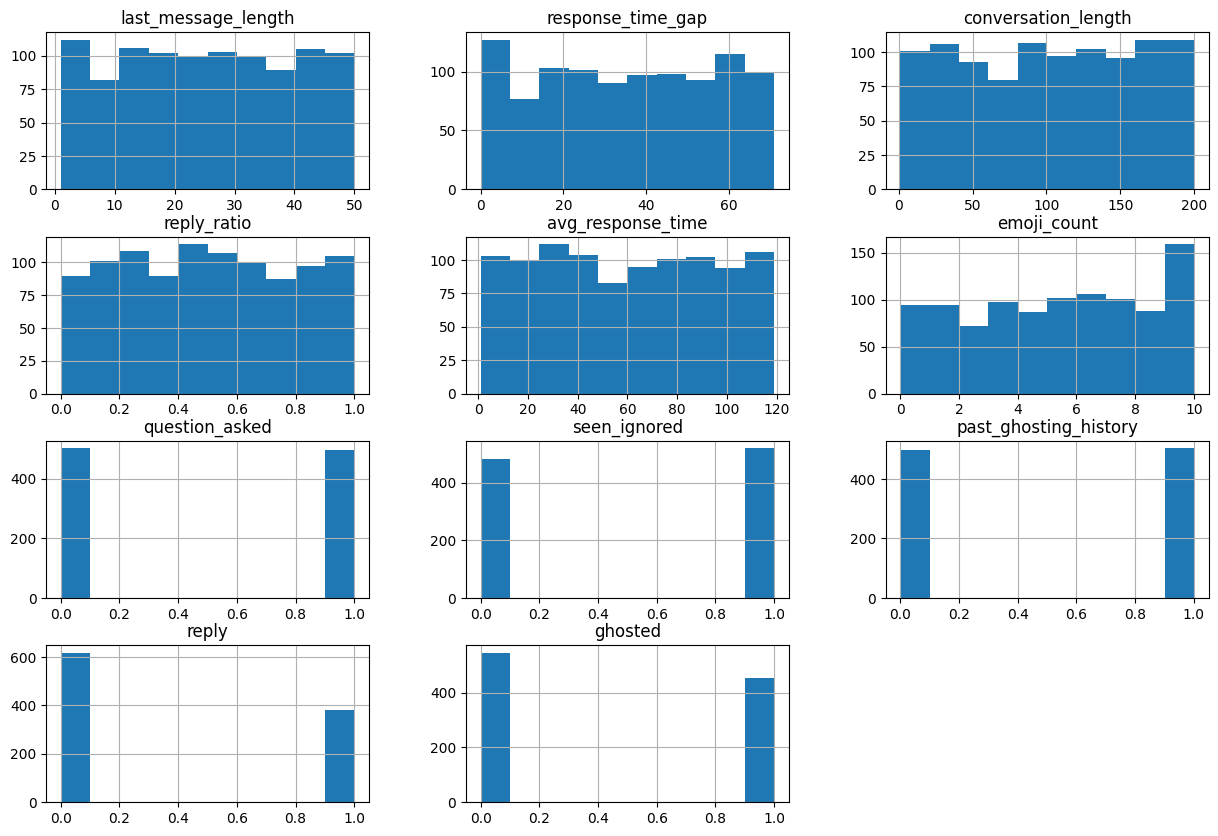

In [1060]:
# performing univariate analysis
df.hist(figsize=(15,10))

<Axes: >

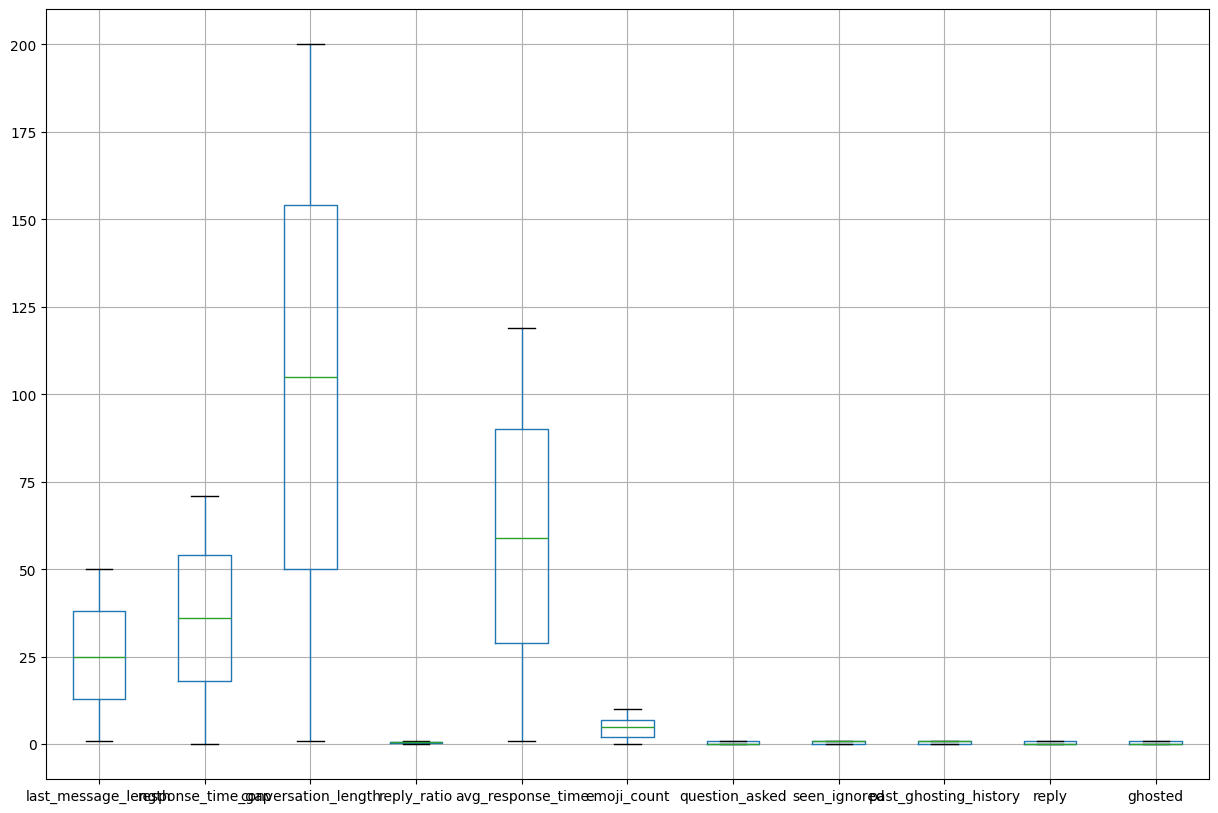

In [1061]:
# box-plot --> for identifying outliers
df.boxplot(figsize=(15,10))

In [1062]:
df.loc[(df['reply'] == 1) & (df['ghosted'] == 1), 'ghosted'] = 0
df[['reply', 'ghosted']].value_counts()

,,count
reply,ghosted,
0,1,454
1,0,382
0,0,164


# ***Feature Engineering***

In [1063]:
df['effort_score'] = df['last_message_length'] + df['emoji_count']

df['is_fast_replier'] = df['avg_response_time'] < 30

df['is_long_gap'] = df['response_time_gap'] > 24

df['engagement_score'] = df['reply_ratio'] * df['conversation_length']

df['late_night_risk'] = (df['time_of_day'] == 'night') & (df['response_time_gap'] > 12)

df['ghost_risk_combo'] = (
    (df['response_time_gap'] > 24) &
    (df['reply_ratio'] < 0.4)
).astype(int)

df['effort_mismatch'] = (
    (df['last_message_length'] > 20) &
    (df['reply_ratio'] < 0.3)
).astype(int)

df['seen_delay'] = (
    (df['seen_ignored'] == 1) &
    (df['response_time_gap'] > 12)
).astype(int)

df['low_engagement'] = (
    (df['emoji_count'] == 0) &
    (df['message_tone'] == 'dry')
).astype(int)


In [1064]:
df.head()

,last_message_length,response_time_gap,initiator,conversation_length,reply_ratio,avg_response_time,message_tone,emoji_count,question_asked,time_of_day,...,ghosted,effort_score,is_fast_replier,is_long_gap,engagement_score,late_night_risk,ghost_risk_combo,effort_mismatch,seen_delay,low_engagement
0,47,9,me,16,0.30,119,enthusiastic,7,0,day,...,0,54,False,False,4.80,False,0,0,0,0
1,1,26,me,166,0.86,38,neutral,4,0,night,...,0,5,False,True,142.76,True,0,0,0,0
2,27,71,me,200,0.15,63,neutral,3,1,day,...,1,30,False,True,30.00,False,1,1,1,0
3,14,4,them,160,0.98,30,enthusiastic,9,0,night,...,0,23,False,False,156.80,False,0,0,0,0
4,46,66,them,57,0.39,106,neutral,6,1,night,...,1,52,False,True,22.23,True,1,0,0,0


# Split data into training and testing sets


In [1065]:
# performing OHE on categorical cols --> because our input cols are categorical
# label encoding is used when our output cols are categorical --> we cannot use it here
# ordinal encoding is used when we have hierarchy in our data --> we cannnot use it here as well

from sklearn.model_selection import train_test_split
X_train_reply, X_test_reply, y_train_reply, y_test_reply = train_test_split(df.drop('reply',axis=1), df['reply'], test_size=0.2, random_state=42)

In [1066]:
X_train_reply.shape, X_test_reply.shape,

((800, 22), (200, 22))

In [1067]:
df.head()

,last_message_length,response_time_gap,initiator,conversation_length,reply_ratio,avg_response_time,message_tone,emoji_count,question_asked,time_of_day,...,ghosted,effort_score,is_fast_replier,is_long_gap,engagement_score,late_night_risk,ghost_risk_combo,effort_mismatch,seen_delay,low_engagement
0,47,9,me,16,0.30,119,enthusiastic,7,0,day,...,0,54,False,False,4.80,False,0,0,0,0
1,1,26,me,166,0.86,38,neutral,4,0,night,...,0,5,False,True,142.76,True,0,0,0,0
2,27,71,me,200,0.15,63,neutral,3,1,day,...,1,30,False,True,30.00,False,1,1,1,0
3,14,4,them,160,0.98,30,enthusiastic,9,0,night,...,0,23,False,False,156.80,False,0,0,0,0
4,46,66,them,57,0.39,106,neutral,6,1,night,...,1,52,False,True,22.23,True,1,0,0,0


In [1068]:
df['reply'].value_counts(normalize=True)
df['ghosted'].value_counts(normalize=True)

,proportion
ghosted,
0,0.546
1,0.454


In [1069]:
df.groupby('message_tone')['reply'].mean()

,reply
message_tone,
dry,0.344828
enthusiastic,0.496970
neutral,0.307692


# ***2. Define Preprocessing Steps***


In [1070]:
numerical_features = ['last_message_length', 'response_time_gap','conversation_length','reply_ratio',
                      'avg_response_time','emoji_count','effort_score','engagement_score','ghost_risk_combo','effort_mismatch','seen_delay','low_engagement']
categorical_features = ['initiator','message_tone','time_of_day','is_fast_replier','is_long_gap','late_night_risk']

In [1071]:
# Create transformers for numerical data (impute missing values, then scale)
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [1072]:
# Create transformers for categorical data (impute missing values, then one-hot encode)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


In [1073]:
# Bundle preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Keep other columns if any
)

## ***3. Create the Full Pipeline***

In [1074]:
# Bundle preprocessing and the final ML model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), # Data transformation
    ('clf', LogisticRegression()) # ML model
])

## ***4. Train the model***

In [1075]:
pipeline.fit(X_train_reply, y_train_reply)          # Automatically scales AND trains
accuracy = pipeline.score(X_test_reply, y_test_reply)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.90


In [1076]:
#printing cross-val-score
cross_val_score(pipeline, X_train_reply, y_train_reply, cv=5)

array([0.9    , 0.90625, 0.8875 , 0.8875 , 0.875  ])

In [1077]:
# genrating validation matrices
y_pred = pipeline.predict(X_test_reply)
print(classification_report(y_test_reply, y_pred))


              precision    recall  f1-score   support

           0       0.98      0.85      0.91       124
           1       0.80      0.97      0.88        76

    accuracy                           0.90       200
   macro avg       0.89      0.91      0.90       200
weighted avg       0.91      0.90      0.90       200



# ***Random Forest***

In [1078]:
pipeline1 = Pipeline(steps=[
    ('preprocessor', preprocessor), # Data transformation
    ('clf', RandomForestClassifier(n_estimators=500, min_samples_split=2, min_samples_leaf=4, max_features=None, max_depth=40, bootstrap=True)) # ML model
])

rf_param_dist = {
    'clf__n_estimators': [100, 200, 400, 500],
    'clf__max_depth': [10, 20, 30, 40, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__bootstrap': [True, False],
    'clf__max_features': ['sqrt', 'log2', None]
}

# 2. Initialize RandomizedSearchCV
# n_iter=20 will randomly pick 20 combinations to test
random_search_rf = RandomizedSearchCV(
    estimator=pipeline1,
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring='f1',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 3. Fit the model
random_search_rf.fit(X_train_reply, y_train_reply)

# 4. View results
print(f"Best RF F1 Score: {random_search_rf.best_score_:.4f}")
print(f"Best RF Params: {random_search_rf.best_params_}")

# 5. Evaluate on test set
test_f1 = random_search_rf.score(X_test_reply, y_test_reply)
print(f"Test Set F1 Score: {test_f1:.4f}")

#printing cross-val-score
cross_val_score(pipeline1, X_train_reply, y_train_reply, cv=5)
cross_val_score

#confusion matrix
y_pred = random_search_rf.predict(X_test_reply)
print(classification_report(y_test_reply, y_pred))


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best RF F1 Score: 0.8804
Best RF Params: {'clf__n_estimators': 400, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 2, 'clf__max_features': 'log2', 'clf__max_depth': 20, 'clf__bootstrap': True}
Test Set F1 Score: 0.8810
              precision    recall  f1-score   support

           0       0.98      0.85      0.91       124
           1       0.80      0.97      0.88        76

    accuracy                           0.90       200
   macro avg       0.89      0.91      0.90       200
weighted avg       0.91      0.90      0.90       200



In [1079]:
pipeline1.fit(X_train_reply, y_train_reply)          # Automatically scales AND trains
accuracy = pipeline1.score(X_test_reply, y_test_reply)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.90


# ***XGBOostClassifier***

In [1080]:
pipeline2 = Pipeline(steps=[
    ('preprocessor', preprocessor), # Data transformation
    ('clf', XGBClassifier(subsample=0.7, n_estimators=200, max_depth=3, learning_rate=0.01, gamma=0.3,
                          colsample_bytree=1.0)) # ML model

])

# 1. Define the parameter distributions with the 'clf__' prefix
# This matches the 'clf' step name in your pipeline2
xgb_param_dist = {
    'clf__n_estimators': [200, 300, 500],
    'clf__max_depth': [3, 5, 7],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__subsample': [0.7, 0.9, 1.0],
    'clf__colsample_bytree': [0.7, 0.9, 1.0],
    'clf__gamma': [0, 0.1, 0.3]
}

# 2. Setup the Randomized Search
# n_iter=50 will test 50 random combinations out of the 729 possible
random_search_xgb = RandomizedSearchCV(
    estimator=pipeline2,
    param_distributions=xgb_param_dist,
    n_iter=50,
    scoring='f1',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 3. Run the search on your training data
random_search_xgb.fit(X_train_reply, y_train_reply)

# 4. Results
print(f"Best XGB F1 Score: {random_search_xgb.best_score_:.4f}")
print(f"Best XGB Params: {random_search_xgb.best_params_}")

# 5. Final evaluation on the test set
test_f1 = random_search_xgb.score(X_test_reply, y_test_reply)
print(f"Test Set F1 Score: {test_f1:.4f}")

#printing cross-val-score
cross_val_score(pipeline2, X_train_reply, y_train_reply, cv=5)
cross_val_score

#confusion matrix
y_pred = random_search_rf.predict(X_test_reply)
print(classification_report(y_test_reply, y_pred))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best XGB F1 Score: 0.8755
Best XGB Params: {'clf__subsample': 0.7, 'clf__n_estimators': 200, 'clf__max_depth': 3, 'clf__learning_rate': 0.01, 'clf__gamma': 0.1, 'clf__colsample_bytree': 0.7}
Test Set F1 Score: 0.8706
              precision    recall  f1-score   support

           0       0.98      0.85      0.91       124
           1       0.80      0.97      0.88        76

    accuracy                           0.90       200
   macro avg       0.89      0.91      0.90       200
weighted avg       0.91      0.90      0.90       200



In [1081]:
pipeline2.fit(X_train_reply, y_train_reply)          # Automatically scales AND trains
accuracy = pipeline2.score(X_test_reply, y_test_reply)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.89


## ***5. Evaluate the model***

In [ ]:
# importing my random Forest model --> 90% accuracy
import joblib
joblib.dump(random_search_rf, 'random_forest_model.pkl')